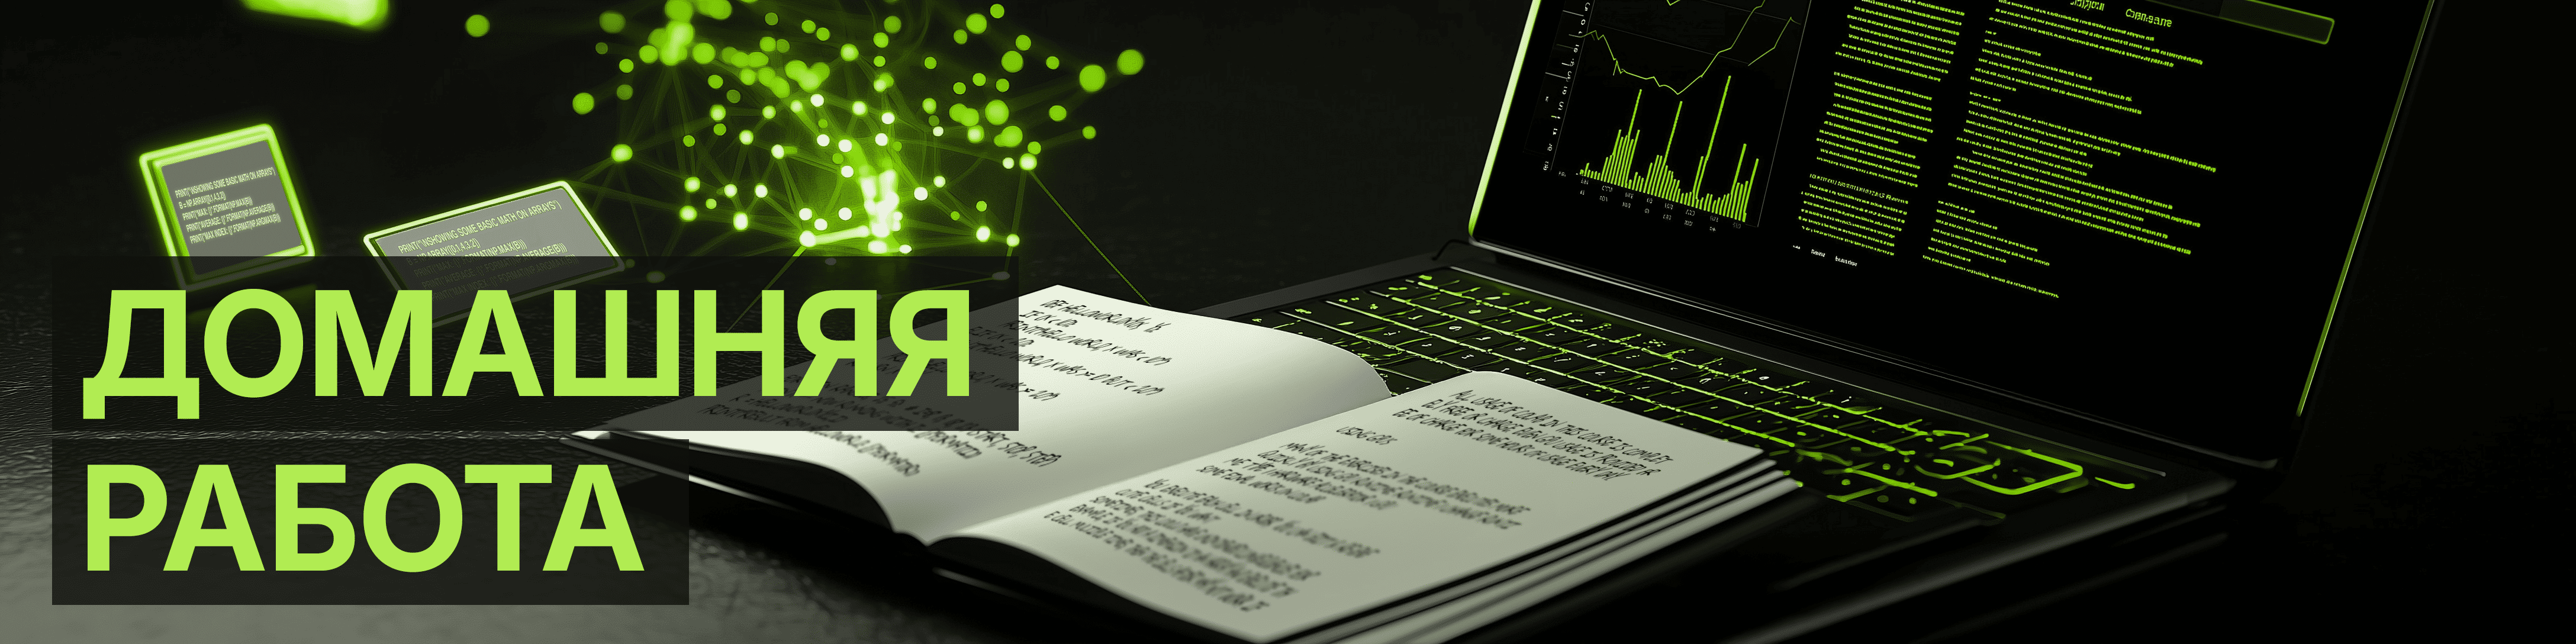

**Навигация по уроку**
1. [Инструменты создания web-интерфейсов](https://colab.research.google.com/drive/1JMj27rzWwL3r6jDqdxHv9Y3LiDgAEAvC)
2. [Создаем интерфейс на Streamlit](https://colab.research.google.com/drive/1THSgc9HQwUA2WfrmD8X7JR97huFSIjC3)
3. [Создание чат-бота на Gradio](https://colab.research.google.com/drive/1LLKuYCFLO-BpCj2PxtELXDP3qMXia8fK)
4. Домашняя работа

В домашней работе вам необходимо создать интерфейс к вашей модели нейронной сети, используя Streamlit (можно и Gradio). Для этого:

1. Определитесь, какую задачу будет решать ваша нейронная сеть.
2. Продумайте интерфейс взаимодействия с пользователем, какими параметрами модели пользователь будет управлять.
3. Обучите модель на любом публичном датасете или возьмите из любого предыдущего урока. Вспомните как происходит загрузка и выгрузка моделей в Keras.
4. Загрузите обученную модель в Colab с интерфейсом (деплой модели).
5. Создайте интерфейс для инференса вашей модели (для запросов к модели).
6. Изучите как происходит загрузка файлов для моделей с помощью Streamlit по [ссылке](https://docs.streamlit.io/develop/api-reference/widgets/st.file_uploader).
7. Добавьте в интерфейс возможность загрузки пользовательских данных для инференса. Это может быть текстовый файл, картинка, аудиофайл или др.
8. Выполнив задание, получите 3 балла.
9. Вы также можете получить дополнительные 2 балла, если реализуете в одном интерфейсе обучение модели и её инференс.

**Инференс** - это процесс исполнения обученных моделей машинного обучения для получения предсказаний на данных, поданных на вход модели.
Обычно нейронная сеть проходит три жизненных этапа: обучение, деплой и инференс. Инференсом называется непрерывная работа какой-либо нейронной сети на конечном устройстве.

**Деплой** - загрузка на сервер.

Постановка задачи:

Задача: Предсказание взвешенной итоговой оценки (Weighted_Total_Score).

Описание задачи: Построить модель, которая будет предсказывать взвешенную итоговую оценку студента на основе различных факторов, таких как посещаемость, средние баллы по заданиям и экзаменам, количество часов учебы в неделю и уровень стресса, с учетом заданных весов для каждого фактора.

Подход:

Тип задачи: Регрессия.
Входные данные: Все характеристики студентов, включая посещаемость, средние баллы по заданиям и экзаменам, количество часов учебы в неделю и уровень стресса, за исключением взвешенной итоговой оценки (Weighted_Total_Score).
Выходные данные: Взвешенная итоговая оценка (Weighted_Total_Score), рассчитанная на основе заданных весов для каждого фактора.

# ***Продумайте интерфейс взаимодействия с пользователем, какими параметрами модели пользователь будет управлять.***
Интерфейс предсказания итоговой оценки студента:

Заголовок
Предсказание итоговой оценки студента

Фактически, пользователь *не управляет* интерфейсом напрямую. Вместо этого, приложение предоставляет два основных функционала:

1.  **Обучение модели:**

    *   **Загрузка данных для обучения:** Пользователь загружает CSV-файл, содержащий данные об успеваемости студентов, которые используются для обучения модели.
    *   **Настройка параметров обучения:**
        *   `Learning Rate`: Пользователь может установить learning rate (скорость обучения) модели.
        *   `Количество эпох`: Пользователь может установить количество эпох (циклов обучения).
        *   `Размер тестовой выборки`: Пользователь может указать размер тестовой выборки.
        *   `Random state`: Пользователь может установить random state.
    *   **Начать обучение:** Пользователь нажимает кнопку "Начать обучение", чтобы запустить процесс обучения модели с использованием загруженных данных и заданных параметров.

2.  **Предсказание итоговой оценки:**

    *   **Загрузка данных для предсказания:** Пользователь загружает CSV-файл, содержащий данные о студентах, для которых необходимо предсказать итоговую оценку. *Важно*: Файл должен содержать те же столбцы, что и файл для обучения.
    *   **Предсказать оценку:** Пользователь нажимает кнопку "Предсказать оценку", чтобы получить предсказанные итоговые оценки для студентов, содержащихся в загруженном файле.

Кнопка действия:
*   **Начать обучение**
*   **Предсказать оценку**
Результаты:
*   Обученная модель сохраняется для дальнейшего использования.
*   Система покажет предполагаемую итоговую оценку студента.

# ***Обучите модель на любом публичном датасете или возьмите из любого предыдущего урока. Вспомните как происходит загрузка и выгрузка моделей в Keras.***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
# Загрузка датасета
data = pd.read_csv('Students_Grading_Dataset.csv')

# Просмотр первых нескольких строк данных
print(data.head())

  Student_ID First_Name Last_Name                    Email  Gender  Age  \
0      S1000       Omar  Williams  student0@university.com  Female   22   
1      S1001      Maria     Brown  student1@university.com    Male   18   
2      S1002      Ahmed     Jones  student2@university.com    Male   24   
3      S1003       Omar  Williams  student3@university.com  Female   24   
4      S1004       John     Smith  student4@university.com  Female   23   

    Department  Attendance (%)  Midterm_Score  Final_Score  ...  \
0  Engineering           52.29          55.03        57.82  ...   
1  Engineering           97.27          97.23        45.80  ...   
2     Business           57.19          67.05        93.68  ...   
3  Mathematics           95.15          47.79        80.63  ...   
4           CS           54.18          46.59        78.89  ...   

   Projects_Score  Total_Score  Grade  Study_Hours_per_Week  \
0           85.90        56.09      F                   6.2   
1           55.65   

In [ ]:
# Проверка на наличие пропущенных значений
print("Проверка на пропущенные значения:")
print(data.isnull().sum())

# Удаление строк с пропущенными значениями (если есть)
data = data.dropna()

# Проверка типов данных
print("Типы данных в датасете:")
print(data.dtypes)

# Преобразование типов данных (если необходимо)
data['Attendance (%)'] = data['Attendance (%)'].astype(float)
data['Age'] = data['Age'].astype(int)
data['Stress_Level (1-10)'] = data['Stress_Level (1-10)'].astype(int)

# Проверка на дубликаты
duplicates = data.duplicated().sum()
if duplicates > 0:
    print(f"Обнаружено {duplicates} дубликатов. Удаляем дубликаты.")
    data = data.drop_duplicates()
else:
    print("Дубликаты не обнаружены.")

Проверка на пропущенные значения:
Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64
Типы данных в датасете:
Student_ID                     object
First_Name                     object
Last_Name                      object
Email     

<ipython-input-4-46313bfea8fd>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Attendance (%)'] = data['Attendance (%)'].astype(float)
<ipython-input-4-46313bfea8fd>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data['Age'].astype(int)
<ipython-input-4-46313bfea8fd>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [ ]:
# Проверка на пропуски и аномалии
print(data.isnull().sum())  # Проверка на NaN
print(data.describe())

Student_ID                    0
First_Name                    0
Last_Name                     0
Email                         0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64
               Age  Attendance (%)  Midterm_Score  Final_Score  \
count  2581.000000     2581.000000    2581.000000  2581.000000   
mean     21.054243       75.376780      70.076897    69.543510   
std       1.999264       14.307085      17.028021    

In [ ]:
import pandas as pd

# Преобразование столбцов типа object в категориальные
categorical_columns = [
    'Student_ID',
    'First_Name',
    'Last_Name',
    'Email',
    'Gender',
    'Department',
    'Grade',
    'Extracurricular_Activities',
    'Internet_Access_at_Home',
    'Parent_Education_Level',
    'Family_Income_Level'
]

for col in categorical_columns:
    data[col] = data[col].astype('category')

# Проверка типов данных после преобразования
print(data.dtypes)

Student_ID                    category
First_Name                    category
Last_Name                     category
Email                         category
Gender                        category
Age                              int64
Department                    category
Attendance (%)                 float64
Midterm_Score                  float64
Final_Score                    float64
Assignments_Avg                float64
Quizzes_Avg                    float64
Participation_Score            float64
Projects_Score                 float64
Total_Score                    float64
Grade                         category
Study_Hours_per_Week           float64
Extracurricular_Activities    category
Internet_Access_at_Home       category
Parent_Education_Level        category
Family_Income_Level           category
Stress_Level (1-10)              int64
Sleep_Hours_per_Night          float64
dtype: object


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Преобразование категориальных переменных в числовые
label_encoders = {}
for column in data.select_dtypes(include=['category']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [ ]:
print(data.dtypes)

Student_ID                      int64
First_Name                      int64
Last_Name                       int64
Email                           int64
Gender                          int64
Age                             int64
Department                      int64
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                           int64
Study_Hours_per_Week          float64
Extracurricular_Activities      int64
Internet_Access_at_Home         int64
Parent_Education_Level          int64
Family_Income_Level             int64
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object


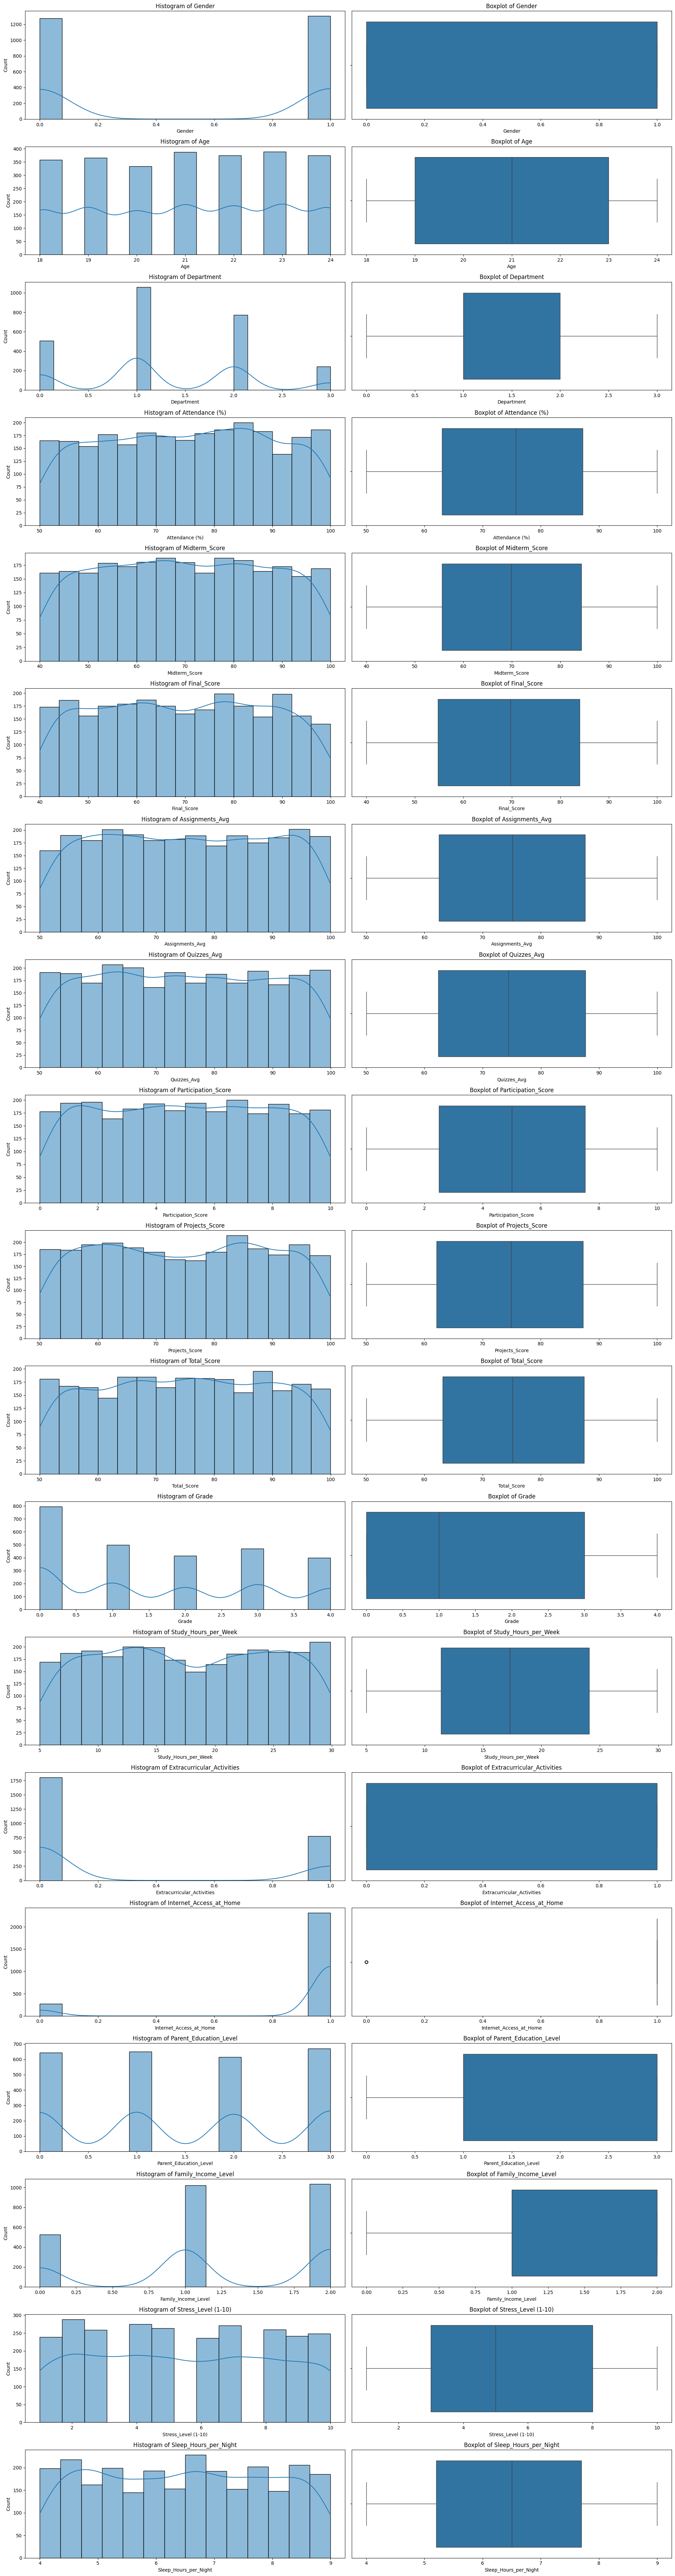

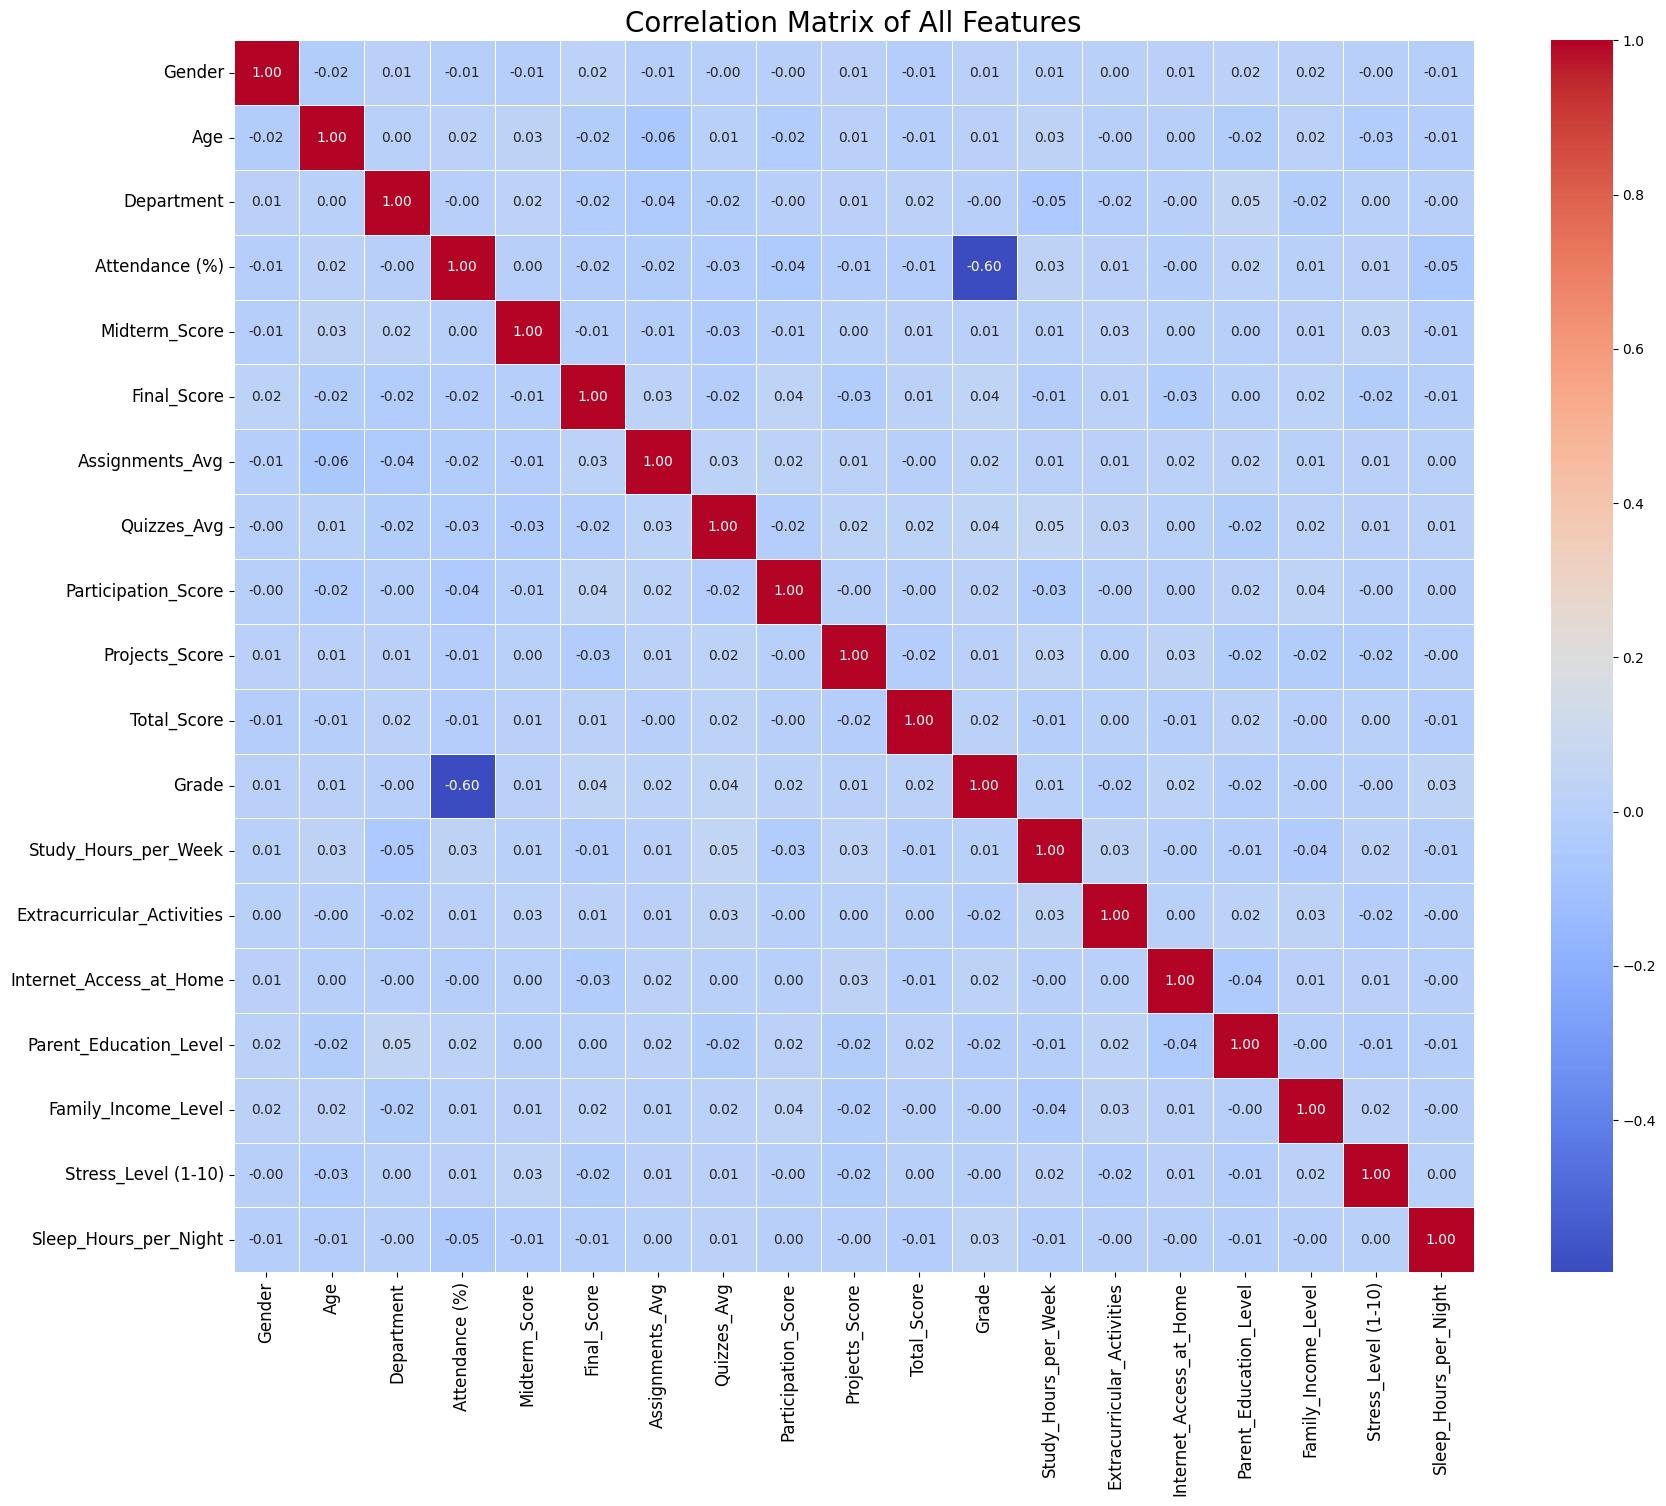

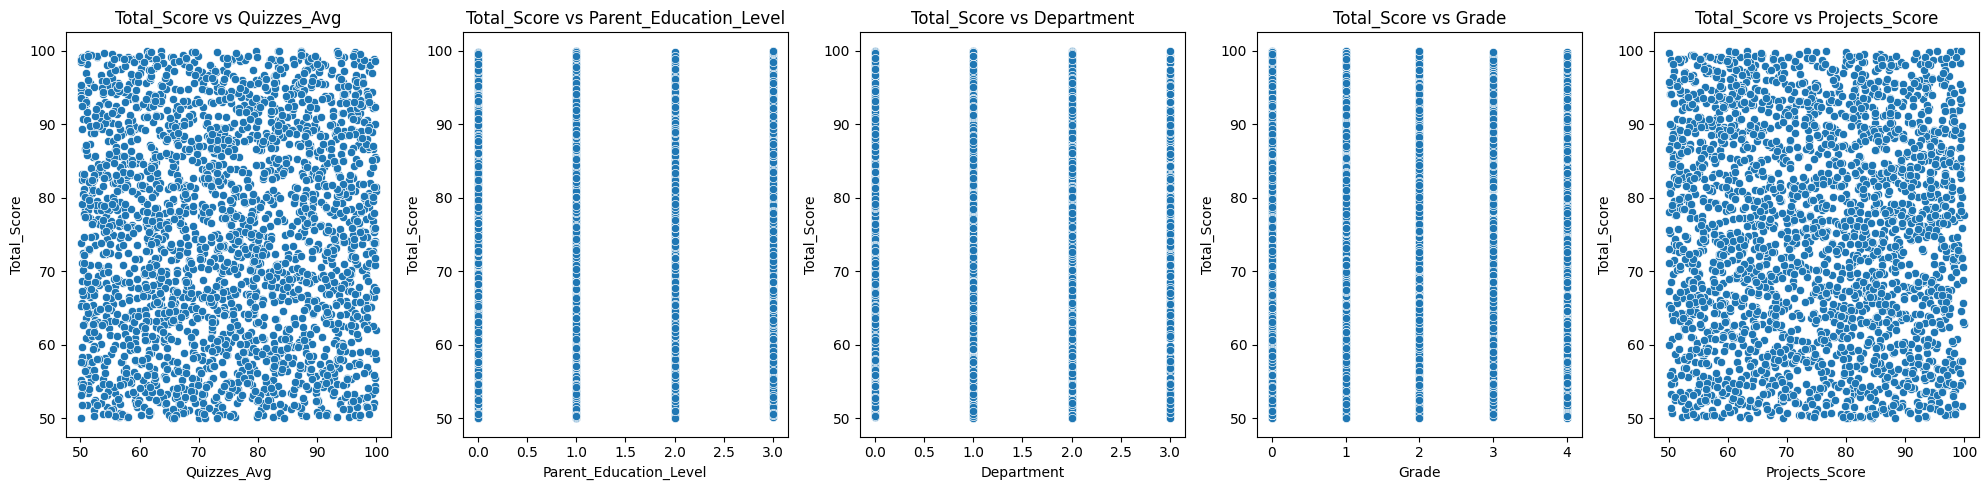

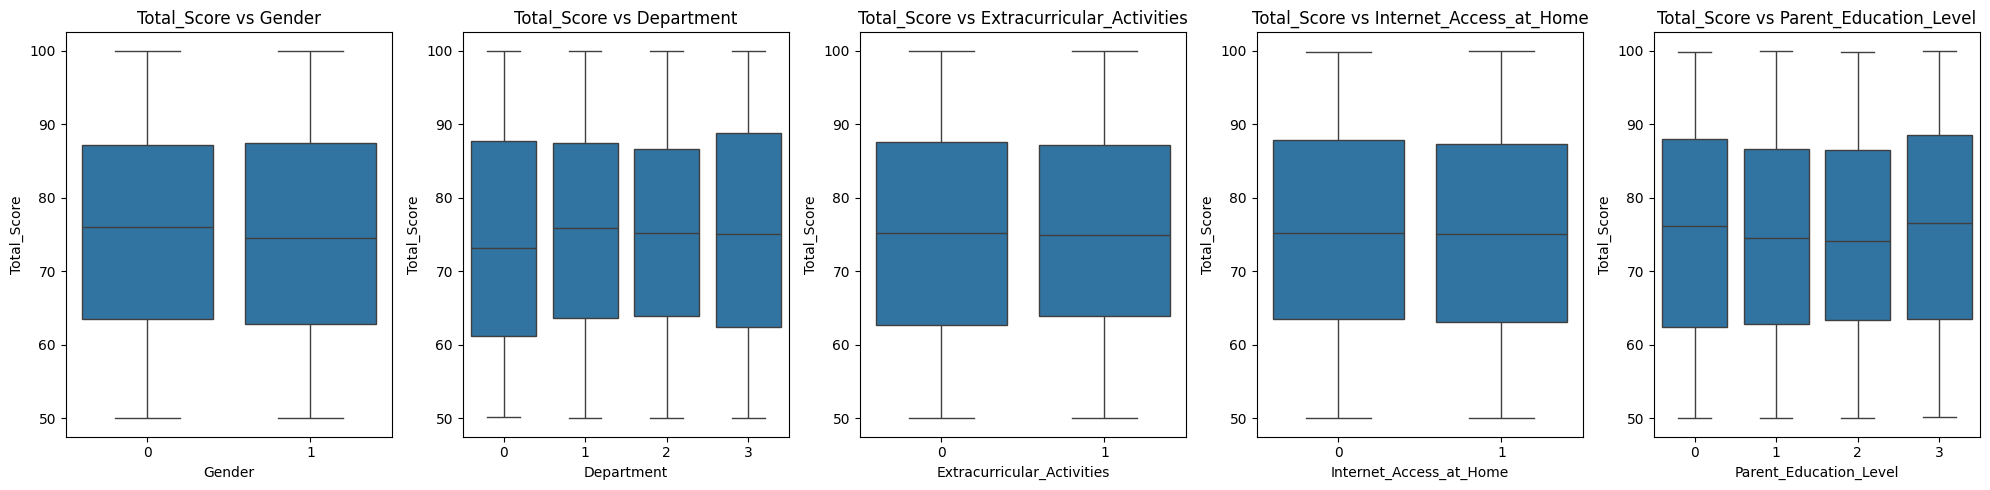

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Удаляем столбцы, которые не нужны для анализа корреляций
data_for_analysis = data.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email'])

# 1. Распределения признаков
numerical_cols = data_for_analysis.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(20, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Гистограмма
    sns.histplot(data_for_analysis[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'Histogram of {col}')

    # Ящик с усами
    sns.boxplot(x=data_for_analysis[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# 2. Матрица корреляций
plt.figure(figsize=(20, 16))
corr_matrix = data_for_analysis.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of All Features", fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# 3. Диаграммы рассеяни
top_correlated_features = corr_matrix['Total_Score'].abs().sort_values(ascending=False)[1:6].index # Top 5 кроме самого Total_Score

fig, axes = plt.subplots(1, len(top_correlated_features), figsize=(20, 5))

for i, feature in enumerate(top_correlated_features):
    sns.scatterplot(x=data_for_analysis[feature], y=data_for_analysis['Total_Score'], ax=axes[i])
    axes[i].set_title(f'Total_Score vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Total_Score')

plt.tight_layout()
plt.show()


# 4. Категориальные признаки vs Total_Score
categorical_cols = ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(20, 5))
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=data_for_analysis[col], y=data_for_analysis['Total_Score'], ax=axes[i])
    axes[i].set_title(f'Total_Score vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Total_Score')

plt.tight_layout()
plt.show()

In [ ]:
data

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,6,5,0,0,22,2,52.29,55.03,57.82,...,85.90,56.09,4,6.2,0,1,1,2,5,4.7
2,1,0,3,1125,1,24,0,57.19,67.05,93.68,...,73.79,70.30,3,20.7,0,1,2,1,6,6.2
3,2,6,5,1727,0,24,3,95.15,47.79,80.63,...,92.12,61.63,0,24.8,1,1,1,0,3,6.7
4,3,3,4,2291,0,23,1,54.18,46.59,78.89,...,68.42,66.13,4,15.4,1,1,1,0,2,7.1
8,4,6,4,2515,0,21,1,85.97,84.42,90.87,...,94.01,95.62,0,8.0,0,0,0,1,9,8.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,2576,2,0,2285,0,22,1,86.09,89.34,64.96,...,68.21,65.03,0,10.2,0,1,3,0,2,8.1
4989,2577,4,0,2286,1,23,2,90.50,40.81,47.07,...,83.03,76.08,0,11.3,0,1,1,1,10,5.8
4997,2578,3,0,2287,0,24,1,87.54,63.55,64.21,...,82.65,54.25,0,24.8,1,0,1,2,4,6.3
4998,2579,7,1,2288,1,23,1,92.56,79.79,94.28,...,94.29,55.84,0,16.1,1,1,0,1,1,8.4


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import PolynomialFeatures
import numpy as np  # Import numpy

# Разделение на признаки и целевую переменную
X = data.drop(columns=['Total_Score', 'Student_ID', 'First_Name', 'Last_Name', 'Email', 'Grade'])
y = data['Total_Score']

# Feature Engineering: Комбинация признаков с помощью PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)  # increased degree
X_poly = poly.fit_transform(X)
# Веса признаков (самые важные)
weights = {
    'Attendance (%)': 0.10,
    'Midterm_Score': 0.25,
    'Final_Score': 0.35,
    'Assignments_Avg': 0.15,
    'Quizzes_Avg': 0.10,
    'Participation_Score': 0.05,
    'Projects_Score': 0.10
}

# Функция для расчета Weighted_Total_Score
def calculate_weighted_total_score(row, weights):
    total_score = (
        (row['Attendance (%)'] * weights['Attendance (%)']) +
        (row['Midterm_Score'] * weights['Midterm_Score']) +
        (row['Final_Score'] * weights['Final_Score']) +
        (row['Assignments_Avg'] * weights['Assignments_Avg']) +
        (row['Quizzes_Avg'] * weights['Quizzes_Avg']) +
        (row['Participation_Score'] * weights['Participation_Score']) +
        (row['Projects_Score'] * weights['Projects_Score'])
    )
    return total_score

# Рассчитываем новый признак Weighted_Total_Score
data['Weighted_Total_Score'] = data.apply(lambda row: calculate_weighted_total_score(row, weights), axis=1)

# Разделение на признаки и целевую переменную
X = data.drop(columns=['Total_Score', 'Student_ID', 'First_Name', 'Last_Name', 'Email', 'Grade', 'Weighted_Total_Score'])
y = data['Weighted_Total_Score']

# Разделение на обучающую, валидационную и тестовую выборки
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape data for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Архитектура модели с Residual Blocks и CNN
def residual_block(x, filters, kernel_size=3):
    res = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
    res = layers.BatchNormalization()(res)
    res = layers.Conv1D(filters, kernel_size, padding='same')(res)
    res = layers.BatchNormalization()(res)
    shortcut = layers.Conv1D(filters, 1, padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([res, shortcut])
    x = layers.Activation('relu')(x)
    return x

def create_model(input_shape):
    input_tensor = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    output_tensor = layers.Dense(1)(x)  # Линейный выход

    model = keras.Model(inputs=input_tensor, outputs=output_tensor)
    return model

# Создание модели
input_shape = (X_train.shape[1], 1)
model = create_model(input_shape)

# Компиляция модели
optimizer = keras.optimizers.Adam(learning_rate=0.001)  # Подстройка learning rate
model.compile(optimizer=optimizer, loss='mae', metrics=['mae']) # Используем MAE

# Learning Rate Scheduler
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# EarlyStopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Вывод структуры модели
model.summary()

# Обучение модели
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping, lr_scheduler])

# Оценка модели
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Absolute Error on Test Set: {mae:.2f}')

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11            │ (None, 17, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_50 (Conv1D)        │ (None, 17, 64)         │            256 │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_56    │ (None, 17, 64)         │            256 │ conv1d_50[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_51 (Conv1D)        │ (None, 17, 64)         │         12,352 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_57    │ (None, 17, 64)         │            256 │ conv1d_51[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_52 (Conv1D)        │ (None, 17, 64)         │         12,352 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_53 (Conv1D)        │ (None, 17, 64)         │          4,160 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_58    │ (None, 17, 64)         │            256 │ conv1d_52[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_59    │ (None, 17, 64)         │            256 │ conv1d_53[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_12 (Add)              │ (None, 17, 64)         │              0 │ batch_normalization_5… │
│                           │                        │                │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_12             │ (None, 17, 64)         │              0 │ add_12[0][0]           │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_54 (Conv1D)        │ (None, 17, 64)         │         12,352 │ activation_12[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_60    │ (None, 17, 64)         │            256 │ conv1d_54[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_55 (Conv1D)        │ (None, 17, 64)         │         12,352 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_56 (Conv1D)        │ (None, 17, 64)         │          4,160 │ activation_12[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6

 Total params: 151,041 (590.00 KB)

 Trainable params: 149,889 (585.50 KB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 67.5295 - mae: 64.2607 - val_loss: 15.9567 - val_mae: 12.7102 - learning_rate: 0.0010
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 22.1882 - mae: 18.9925 - val_loss: 9.1891 - val_mae: 6.1478 - learning_rate: 0.0010
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 16.6362 - mae: 13.6234 - val_loss: 18.8992 - val_mae: 15.9887 - learning_rate: 0.0010
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 15.1688 - mae: 12.2984 - val_loss: 18.0509 - val_mae: 15.2868 - learning_rate: 0.0010
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 14.0495 - mae: 11.3160 - val_loss: 17.5710 - val_mae: 14.9143 - learning_rate: 0.0010
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 12.9770 - mae: 10.3452 - val_loss: 16.9588 - val_mae: 14.3974 - learning_rate: 0.0010
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 13.1223 - mae: 10.5885 - val_loss: 13.0140 - val_mae: 10.5596 - l

Задача:

Я пытался создать модель машинного обучения, которая могла бы предсказывать итоговую оценку студента (Total_Score) на основе разных факторов (посещаемость, оценки за экзамены и т.д.).

Что я делал:
Начал с простого:

Сначала я создал очень простую модель, чтобы убедиться, что вообще возможно предсказать итоговую оценку на основе имеющихся данных.

Становилось все сложнее:

Затем я постепенно усложнял модель, добавляя больше слоев, регуляризацию и разные архитектуры (например, CNN с residual blocks).

Экспериментировал с данными:

Я пробовал разные способы масштабирования данных (StandardScaler, RobustScaler, MinMaxScaler) и добавлял новые признаки (например, полиномиальные признаки).
Искал причины неудач:

 Я анализировал графики и метрики, чтобы понять, почему модель не работает так, как мне хотелось бы.

Пересмотрел задачу:

Когда ничего не помогало, я понял, что, возможно, проблема не в модели, а в данных или в самой задаче.
Изменил подход: Я решил, что исходная итоговая оценка (Total_Score) могла быть рассчитана неоптимально, поэтому я создал свою собственную итоговую оценку (Weighted_Total_Score), в которой я сам задал веса для разных компонентов (посещаемость, оценки за экзамены и т.д.).

Сосредоточился на предсказании новой оценки:

Я переобучил модель, чтобы она предсказывала мою новую итоговую оценку (Weighted_Total_Score), и удалил старую оценку из входных данных, чтобы модель не “подглядывала”.
Результат:

В итоге, когда я стал предсказывать свою собственную итоговую оценку (Weighted_Total_Score), модель начала работать значительно лучше. Это произошло потому, что я сделал задачу более четкой и управляемой для модели.

# ***Загрузите обученную модель в Colab с интерфейсом (деплой модели).***


In [ ]:
# Сохранение model и scaler (как и раньше)
model.save('student_model.h5')
joblib.dump(scaler, 'scaler.joblib')

# Сохранение label encoders
joblib.dump(label_encoders, 'label_encoders.joblib') # Сохраняем label_encoders
print("Label encoders saved as label_encoders.joblib")

Label encoders saved as label_encoders.joblib


# ***Создайте интерфейс для инференса вашей модели (для запросов к модели).***

# ***Изучите как происходит загрузка файлов для моделей с помощью Streamlit по ссылке.***

# ***Добавьте в интерфейс возможность загрузки пользовательских данных для инференса. Это может быть текстовый файл, картинка, аудиофайл или др.***

In [ ]:
!pip install -q streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
%%writefile main.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder # Импортируем LabelEncoder

# Загрузка модели и scaler
try:
    model = tf.keras.models.load_model('student_model.h5', custom_objects={'mae': tf.keras.metrics.MeanAbsoluteError()})
    scaler = joblib.load('scaler.joblib')
    # Загрузка label encoders
    try:
      label_encoders = joblib.load('label_encoders.joblib') # Загружаем label_encoders
    except:
      label_encoders = {}
except Exception as e:
    st.error(f"Ошибка при загрузке модели, scaler или label encoders: {e}")
    model = None
    scaler = None
    label_encoders = None

# Веса признаков (самые важные) - из твоего обучающего скрипта
weights = {
    'Attendance (%)': 0.10,
    'Midterm_Score': 0.25,
    'Final_Score': 0.35,
    'Assignments_Avg': 0.15,
    'Quizzes_Avg': 0.10,
    'Participation_Score': 0.05,
    'Projects_Score': 0.10
}

# Функция для расчета Weighted_Total_Score
def calculate_weighted_total_score(row, weights):
    total_score = (
        (row['Attendance (%)'] * weights['Attendance (%)']) +
        (row['Midterm_Score'] * weights['Midterm_Score']) +
        (row['Final_Score'] * weights['Final_Score']) +
        (row['Assignments_Avg'] * weights['Assignments_Avg']) +
        (row['Quizzes_Avg'] * weights['Quizzes_Avg']) +
        (row['Participation_Score'] * weights['Participation_Score']) +
        (row['Projects_Score'] * weights['Projects_Score'])
    )
    return total_score

# Функция для предсказания
def predict_score(input_data):
    try:
        # 1. ОПРЕДЕЛИТЬ НЕОБХОДИМЫЕ СТОЛБЦЫ
        required_columns = ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

        # 2. УДАЛИТЬ ЛИШНИЕ СТОЛБЦЫ
        for column in input_data.columns:
            if column not in required_columns:
                input_data = input_data.drop(column, axis=1)

        # 3. ПРОВЕРИТЬ НАЛИЧИЕ НЕОБХОДИМЫХ СТОЛБЦОВ
        missing_columns = [col for col in required_columns if col not in input_data.columns]
        if missing_columns:
            st.error(f"В данных отсутствуют следующие столбцы: {', '.join(missing_columns)}")
            return None

        # Преобразование столбцов в числовой тип
        for column in required_columns:
            if column in input_data.columns:
                # Пытаемся преобразовать столбец в числовой тип
                input_data[column] = pd.to_numeric(input_data[column], errors='coerce')
                # Заполняем отсутствующие значения:
                # 1. Пытаемся заполнить медианой
                median = input_data[column].median()
                if pd.isna(median):
                    # 2. Если медиана NaN, заполняем нулем
                    input_data[column] = input_data[column].fillna(0)
                else:
                    input_data[column] = input_data[column].fillna(median)

        # Проверяем наличие NaN значений после обработки числовых столбцов
        if input_data.isnull().values.any():
            st.error(f"В данных есть NaN значения после обработки числовых столбцов.  Проверьте, что все столбцы содержат корректные числовые значения.")
            return None

        # Рассчитать Weighted_Total_Score
        input_data['Weighted_Total_Score'] = input_data.apply(lambda row: calculate_weighted_total_score(row, weights), axis=1)

        # Масштабировать данные
        scaled_data = scaler.transform(input_data.drop(columns=['Weighted_Total_Score']))

        # Проверяем наличие NaN значений после масштабирования
        if np.isnan(scaled_data).any():
            st.error(f"В масштабированных данных есть NaN значения. Проверьте данные и scaler.")
            return None


        # Reshape для CNN
        scaled_data = scaled_data.reshape(scaled_data.shape[0], scaled_data.shape[1], 1)

        # Сделать предсказание
        prediction = model.predict(scaled_data)[0][0] # Получаем одно число из предсказания
        return prediction

    except Exception as e:
        st.error(f"Ошибка во время предсказания: {e}")
        return None


# Streamlit интерфейс
st.title("Предсказание итоговой оценки студента")

# Загрузка данных из CSV файла
uploaded_file = st.file_uploader("Загрузите CSV файл с данными студента", type="csv")

if uploaded_file is not None:
    try:
        input_df = pd.read_csv(uploaded_file)

        # 1. ОПРЕДЕЛИТЬ НЕОБХОДИМЫЕ СТОЛБЦЫ
        required_columns = ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

        # 2. УДАЛИТЬ ЛИШНИЕ СТОЛБЦЫ
        for column in input_df.columns:
            if column not in required_columns:
                input_df = input_df.drop(column, axis=1)

        # 3. ПРОВЕРИТЬ НАЛИЧИЕ НЕОБХОДИМЫХ СТОЛБЦОВ
        missing_columns = [col for col in required_columns if col not in input_df.columns]
        if missing_columns:
            st.error(f"В загруженном файле отсутствуют следующие столбцы: {', '.join(missing_columns)}")
        else:
            categorical_columns = ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level']

            # Преобразование категориальных переменных с помощью загруженных LabelEncoders
            for column in categorical_columns:
                if column in input_df.columns:  # Проверяем, есть ли столбец в DataFrame
                    # Заполняем отсутствующие значения наиболее часто встречающимся значением в столбце
                    most_frequent_value = input_df[column].mode()[0]
                    input_df[column] = input_df[column].fillna(most_frequent_value)

                    #Проверяем, существует ли LabelEncoder для данного столбца
                    if column not in label_encoders:
                        le = LabelEncoder()
                        le.fit(input_df[column].astype(str).unique())
                        label_encoders[column] = le
                    # Преобразуем строки в числа, используя LabelEncoder
                    input_df[column] = label_encoders[column].transform(input_df[column].astype(str))
                else:
                    st.warning(f"Столбец {column} отсутствует в данных. Пропускаем преобразование.")



            # Предсказание
            if st.button("Предсказать оценку"):
                prediction = predict_score(input_df.copy())

                if prediction is not None:
                    st.success(f"Предсказанная итоговая оценка: {prediction:.2f}")

    except Exception as e:
        st.error(f"Ошибка при обработке файла: {e}")

else:
    st.info("Загрузите CSV файл для предсказания.")

Overwriting main.py


In [ ]:
# Выполняем команды для запуска Streamlit и проброса порта через serveo.net
!streamlit run main.py --server.address=localhost >/content/logs.txt & ssh -o "StrictHostKeyChecking no" -R 80:localhost:8501 serveo.net

Forwarding HTTP traffic from https://45656660eccdea24987bf5273f029318.serveo.net
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/static/media/SourceSansPro-Regular.DZLUzqI4.woff2
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/static/media/SourceSansPro-Bold.-6c9oR8J.woff2
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/static/css/index.BOl9eq08.css
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/static/media/SourceSansPro-SemiBold.sKQIyTMz.woff2
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/static/js/index.B-cSXLfy.js
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serveo.net/_stcore/health
HTTP request from 109.233.236.24 to https://45656660eccdea24987bf5273f029318.serv

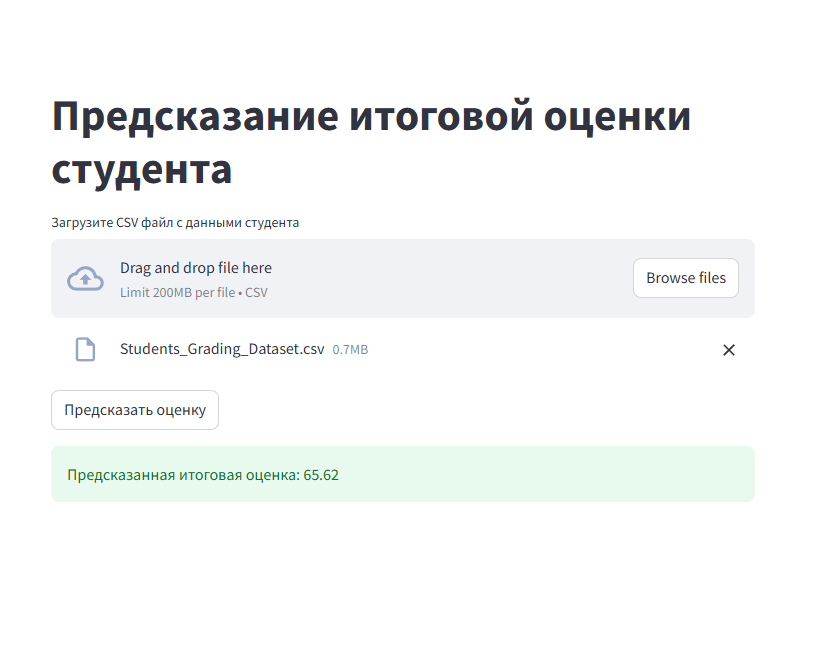

При разработке интерфейса предсказания я столкнулся со следующими трудностями:

Валидация входных данных:

Обеспечение соответствия структуры и типов данных, предоставляемых пользователем, требованиям обученной модели. Реализовано путем проверки наличия необходимых столбцов, удаления лишних и преобразования типов данных.

Обработка категориальных признаков:

Трансформация категориальных переменных в числовой формат с использованием сохраненных LabelEncoders для поддержания консистентности с обучением.
Динамическое создание LabelEncoders при обнаружении новых категорий.

Обработка пропущенных значений:

Заполнение NaN значений медианой столбца для обеспечения корректной работы StandardScaler и модели.

Предотвращение ошибок масштабирования:

Контроль за наличием NaN значений после преобразования типов и масштабирования для избежания ошибок предсказания.

Отказоустойчивость:

Реализация try-except блоков для обработки исключений и предоставления информативных сообщений об ошибках пользователю.

# ***Реализовать в одном интерфейсе обучение модели и её инференс.***

In [ ]:
%%writefile main.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers
import keras

st.title("Обучение и предсказание итоговой оценки студента")

# *** 1. ЗАГРУЗКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ ***
st.header("1. Загрузка данных для обучения")
train_file = st.file_uploader("Загрузите CSV файл для обучения модели", type="csv")

# *** ОПРЕДЕЛЯЕМ ФУНКЦИЮ ДЛЯ ОБУЧЕНИЯ МОДЕЛИ ***
def train_model(train_data, learning_rate, epochs, test_size, random_state):
    try:
        # === Код обучения модели (из предыдущих примеров, адаптированный) ===

        # Веса признаков (самые важные)
        weights = {
            'Attendance (%)': 0.10,
            'Midterm_Score': 0.25,
            'Final_Score': 0.35,
            'Assignments_Avg': 0.15,
            'Quizzes_Avg': 0.10,
            'Participation_Score': 0.05,
            'Projects_Score': 0.10
        }

        # Функция для расчета Weighted_Total_Score
        def calculate_weighted_total_score(row, weights):
            total_score = (
                (row['Attendance (%)'] * weights['Attendance (%)']) +
                (row['Midterm_Score'] * weights['Midterm_Score']) +
                (row['Final_Score'] * weights['Final_Score']) +
                (row['Assignments_Avg'] * weights['Assignments_Avg']) +
                (row['Quizzes_Avg'] * weights['Quizzes_Avg']) +
                (row['Participation_Score'] * weights['Participation_Score']) +
                (row['Projects_Score'] * weights['Projects_Score'])
            )
            return total_score

        # Рассчитываем новый признак Weighted_Total_Score
        train_data['Weighted_Total_Score'] = train_data.apply(lambda row: calculate_weighted_total_score(row, weights), axis=1)

        # Предполагаемые категориальные столбцы
        categorical_columns = ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level']

        # Дополнительные столбцы для Label Encoding
        label_encode_cols = ['Family_Income_Level', 'Stress_Level (1-10)']

        # Преобразование категориальных переменных
        label_encoders = {}
        for column in categorical_columns:
            le = LabelEncoder()
            train_data[column] = le.fit_transform(train_data[column])
            label_encoders[column] = le

        # Label Encoding для Family_Income_Level и Stress_Level (1-10)
        for col in label_encode_cols:
            le = LabelEncoder()
            train_data[col] = le.fit_transform(train_data[col])
            label_encoders[col] = le # Сохраняем LabelEncoder и для этих столбцов


        # Преобразование столбцов в числовой тип
        required_columns = ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']
        for column in required_columns:
            if column in train_data.columns:
                train_data[column] = pd.to_numeric(train_data[column], errors='coerce')
                train_data[column] = train_data[column].fillna(train_data[column].median()) # Или 0, или что-то другое


        # Разделение на признаки и целевую переменную
        X = train_data.drop(columns=['Total_Score', 'Student_ID', 'First_Name', 'Last_Name', 'Email', 'Grade', 'Weighted_Total_Score'])
        y = train_data['Weighted_Total_Score']

        # *** УДАЛЯЕМ NaN ИЗ Y ПЕРЕД РАЗДЕЛЕНИЕМ ***
        nan_mask = y.isnull()
        if nan_mask.any():
            st.warning("Обнаружены NaN значения в целевой переменной (y). Удаляем соответствующие строки.")
            X = X[~nan_mask]
            y = y[~nan_mask]

        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

        # Масштабирование
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)

        # Проверка и замена NaN после масштабирования
        if np.isnan(X_train).any():
            st.error("В X_train есть NaN после масштабирования. Проверьте данные.")
            return None, None, None  # Теперь return работает, так как мы внутри функции

        # То же самое для X_test
        X_test = scaler.transform(X_test)
        if np.isnan(X_test).any():
            st.error("В X_test есть NaN после масштабирования. Проверьте данные.")
            return None, None, None  # Теперь return работает, так как мы внутри функции

        # Reshape data for CNN
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

        # Архитектура модели с Residual Blocks и CNN
        def residual_block(x, filters, kernel_size=3):
            res = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
            res = layers.BatchNormalization()(res)
            res = layers.Conv1D(filters, kernel_size, padding='same')(res)
            res = layers.BatchNormalization()(res)
            shortcut = layers.Conv1D(filters, 1, padding='same')(x)
            shortcut = layers.BatchNormalization()(shortcut)
            x = layers.Add()([res, shortcut])
            x = layers.Activation('relu')(x)
            return x

        def create_model(input_shape):
            input_tensor = keras.Input(shape=input_shape)
            x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_tensor)
            x = layers.BatchNormalization()(x)

            x = residual_block(x, 64)
            x = residual_block(x, 64)

            x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
            x = layers.BatchNormalization()(x)

            x = layers.GlobalAveragePooling1D()(x)

            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
            x = layers.Dropout(0.5)(x)

            output_tensor = layers.Dense(1)(x)  # Линейный выход

            model = keras.Model(inputs=input_tensor, outputs=output_tensor)
            return model

        # Создание модели
        input_shape = (X_train.shape[1], 1)
        model = create_model(input_shape)

        # Компиляция модели
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)  # Подстройка learning rate
        model.compile(optimizer=optimizer, loss='mae', metrics=['mae']) # Используем MAE

        # Learning Rate Scheduler
        lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

        # EarlyStopping
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # Вывод структуры модели
        # model.summary()

        # Обучение модели
        history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, validation_split=0.1, callbacks=[early_stopping, lr_scheduler], verbose=0) #validation_data=(X_val, y_val)

        # Проверка на NaN перед оценкой
        if np.isnan(X_test).any():
            st.error("В X_test есть NaN значения перед оценкой модели.")
            return None, None, None  # Теперь return работает, так как мы внутри функции
        if np.isnan(y_test).any():
            st.error("В y_test есть NaN значения перед оценкой модели.")
            return None, None, None  # Теперь return работает, так как мы внутри функции

        # Оценка модели
        loss, mae = model.evaluate(X_test, y_test, verbose=0)
        st.success(f'Mean Absolute Error на тестовой выборке: {mae:.2f}')

        # Сохранение модели, scaler и label_encoders
        model.save('trained_model.h5')
        joblib.dump(scaler, 'trained_scaler.joblib')
        joblib.dump(label_encoders, 'trained_label_encoders.joblib')
        st.success("Модель успешно обучена и сохранена!")

        return model, scaler, label_encoders

        # === Конец кода обучения модели ===

    except Exception as e:
        st.error(f"Ошибка во время обучения модели: {e}")
        return None, None, None

if train_file is not None:
    try:
        train_data = pd.read_csv(train_file)
        st.success("Данные для обучения успешно загружены!")

        # *** 2. НАСТРОЙКА ПАРАМЕТРОВ ОБУЧЕНИЯ ***
        st.header("2. Настройка параметров обучения")
        learning_rate = st.slider("Learning Rate", 0.0001, 0.01, 0.001, step=0.0001)
        epochs = st.slider("Количество эпох", 5, 50, 10, step=1)
        test_size = st.slider("Размер тестовой выборки", 0.1, 0.5, 0.2, step=0.05)
        random_state = st.number_input("Random state", value=42)

        # *** 3. ОБУЧЕНИЕ МОДЕЛИ ***
        st.header("3. Обучение модели")
        if st.button("Начать обучение"):
            model, scaler, label_encoders = train_model(train_data.copy(), learning_rate, epochs, test_size, random_state) # Важно передавать копию

            if model is None:
                st.error("Обучение модели не удалось.")
            else:
                st.session_state.model = model
                st.session_state.scaler = scaler
                st.session_state.label_encoders = label_encoders
                st.success("Модель обучена и готова к предсказаниям!")


    except Exception as e:
        st.error(f"Ошибка при загрузке данных для обучения: {e}")

# *** 4. ЗАГРУЗКА ДАННЫХ ДЛЯ ПРЕДСКАЗАНИЯ ***
st.header("4. Загрузка данных для предсказания")
predict_file = st.file_uploader("Загрузите CSV файл для предсказания", type="csv")

if predict_file is not None:
    try:
        predict_data = pd.read_csv(predict_file)
        st.success("Данные для предсказания успешно загружены!")

        # *** 5. ПРЕДСКАЗАНИЕ ***
        st.header("5. Предсказание")
        if st.button("Предсказать оценку"):
            try:
                # Проверяем, была ли обучена модель
                if 'model' not in st.session_state:
                    st.error("Модель не обучена. Пожалуйста, загрузите данные и обучите модель.")
                else:
                    model = st.session_state.model
                    scaler = st.session_state.scaler
                    label_encoders = st.session_state.label_encoders
                    # === Код предсказания (из предыдущих примеров, адаптированный) ===
                    # Веса признаков (самые важные)
                    weights = {
                        'Attendance (%)': 0.10,
                        'Midterm_Score': 0.25,
                        'Final_Score': 0.35,
                        'Assignments_Avg': 0.15,
                        'Quizzes_Avg': 0.10,
                        'Participation_Score': 0.05,
                        'Projects_Score': 0.10
                    }

                    # Функция для расчета Weighted_Total_Score
                    def calculate_weighted_total_score(row, weights):
                        total_score = (
                            (row['Attendance (%)'] * weights['Attendance (%)']) +
                            (row['Midterm_Score'] * weights['Midterm_Score']) +
                            (row['Final_Score'] * weights['Final_Score']) +
                            (row['Assignments_Avg'] * weights['Assignments_Avg']) +
                            (row['Quizzes_Avg'] * weights['Quizzes_Avg']) +
                            (row['Participation_Score'] * weights['Participation_Score']) +
                            (row['Projects_Score'] * weights['Projects_Score'])
                        )
                        return total_score

                    def predict_score(input_data):
                        try:
                            # 1. ОПРЕДЕЛИТЬ НЕОБХОДИМЫЕ СТОЛБЦЫ
                            required_columns = ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

                            # 2. УДАЛИТЬ ЛИШНИЕ СТОЛБЦЫ
                            for column in input_data.columns:
                                if column not in required_columns:
                                    input_data = input_data.drop(column, axis=1)

                            # 3. ПРОВЕРИТЬ НАЛИЧИЕ НЕОБХОДИМЫХ СТОЛБЦОВ
                            missing_columns = [col for col in required_columns if col not in input_data.columns]
                            if missing_columns:
                                st.error(f"В данных отсутствуют следующие столбцы: {', '.join(missing_columns)}")
                                return None # ВАЖНО: Возвращаем None, чтобы остановить выполнение

                            # Преобразование столбцов в числовой тип
                            for column in required_columns:
                                if column in input_data.columns:
                                    # Пытаемся преобразовать столбец в числовой тип
                                    input_data[column] = pd.to_numeric(input_data[column], errors='coerce')
                                    # Заполняем отсутствующие значения:
                                    # 1. Пытаемся заполнить медианой
                                    median = input_data[column].median()
                                    if pd.isna(median):
                                        # 2. Если медиана NaN, заполняем нулем
                                        input_data[column] = input_data[column].fillna(0)
                                    else:
                                        input_data[column] = input_data[column].fillna(median)

                            # Проверяем наличие NaN значений после обработки числовых столбцов
                            if input_data.isnull().values.any():
                                st.error(f"В данных есть NaN значения после обработки числовых столбцов.  Проверьте, что все столбцы содержат корректные числовые значения.")
                                return None

                             # Преобразование категориальных переменных с помощью загруженных LabelEncoders
                            categorical_columns = ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level']
                            for column in categorical_columns:
                                if column in input_data.columns:
                                    most_frequent_value = input_data[column].mode()[0]
                                    input_data[column] = input_data[column].fillna(most_frequent_value)

                                    if column not in label_encoders:
                                        le = LabelEncoder()
                                        le.fit(input_data[column].astype(str).unique())
                                        label_encoders[column] = le
                                    input_data[column] = label_encoders[column].transform(input_data[column].astype(str))


                            # Рассчитать Weighted_Total_Score
                            input_data['Weighted_Total_Score'] = input_data.apply(lambda row: calculate_weighted_total_score(row, weights), axis=1)

                            # Масштабировать данные
                            scaled_data = scaler.transform(input_data.drop(columns=['Weighted_Total_Score']))

                            # Проверяем наличие NaN значений после масштабирования
                            if np.isnan(scaled_data).any():
                                st.error(f"В масштабированных данных есть NaN значения. Проверьте данные и scaler.")
                                return None

                            # Reshape для CNN
                            scaled_data = scaled_data.reshape(scaled_data.shape[0], scaled_data.shape[1], 1)

                            # Сделать предсказание
                            prediction = model.predict(scaled_data)[0][0] # Получаем одно число из предсказания
                            return prediction

                        except Exception as e:
                            st.error(f"Ошибка во время предсказания: {e}")
                            return None

                    # Используем функцию predict_score для получения предсказания
                    prediction = predict_score(predict_data.copy())

                    if prediction is not None:
                        st.success(f"Предсказанная итоговая оценка: {prediction:.2f}")
                    # === Конец кода предсказания ===

            except Exception as e:
                st.error(f"Ошибка во время предсказания: {e}")
    except Exception as e:
        st.error(f"Ошибка при загрузке данных для предсказания: {e}")

Overwriting main.py


In [ ]:
# Выполняем команды для запуска Streamlit и проброса порта через serveo.net
!streamlit run main.py --server.address=localhost >/content/logs.txt & ssh -o "StrictHostKeyChecking no" -R 80:localhost:8501 serveo.net

Forwarding HTTP traffic from https://f18a9ae6f8b8e3a168f3218a4fb5a0c9.serveo.net


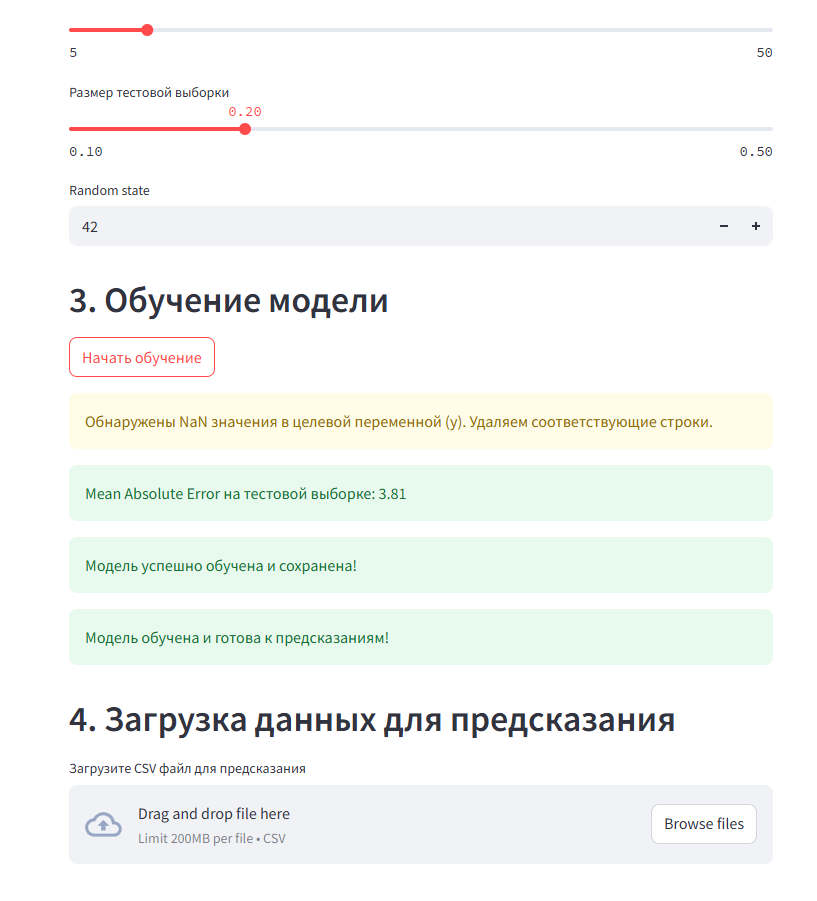